In [91]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(np.float64(-0.5), np.float64(368.5), np.float64(368.5), np.float64(-0.5))

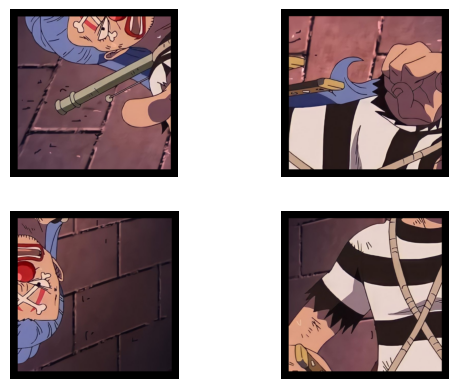

In [92]:
img1 = cv2.imread('assets/buggy1.png')
img2 = cv2.imread('assets/buggy2.png')
img3 = cv2.imread('assets/buggy3.png')
img4 = cv2.imread('assets/buggy4.png')

img1 = cv2.cvtColor(img1,cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2,cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3,cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4,cv2.COLOR_BGR2RGB)

plt.subplot(2,2,1)
plt.imshow(img1)
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img2)
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img3)
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img4)
plt.axis('off')


Dapat dilihat bahwa keempat citra di atas merupakan satu citra utuh yang dibagi menjadi 4. Setiap bagian dari citra ada yang diputar dan ada yang dibalik. Pada responsi ini, saya bertugas untuk mengembalikan citra ke bentuk aslinya dengan melakukan pengolahan citra digital.

(np.float64(-0.5), np.float64(368.5), np.float64(368.5), np.float64(-0.5))

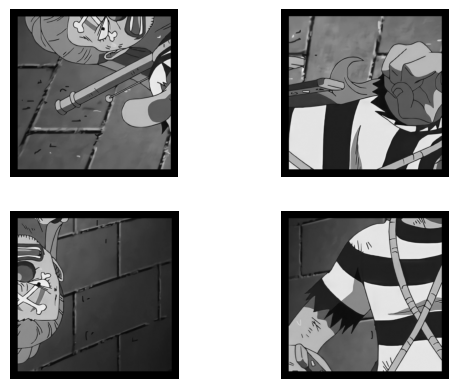

In [93]:
img1_gray = cv2.cvtColor(img1,cv2.COLOR_RGB2GRAY)
img2_gray = cv2.cvtColor(img2,cv2.COLOR_RGB2GRAY)
img3_gray = cv2.cvtColor(img3,cv2.COLOR_RGB2GRAY)
img4_gray = cv2.cvtColor(img4,cv2.COLOR_RGB2GRAY)

plt.subplot(2,2,1)
plt.imshow(img1_gray,cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img2_gray,cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img3_gray,cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img4_gray,cmap='gray')
plt.axis('off')


Dapat dilihat bahwa keempat citra diubah format-nya ke bentuk grayscale. Hal ini dilakukan untuk mempermudah pengolahan citra menjadi bentuk citra aslinya. Grayscale mempermudah karena pengolahan citra dapat dilakukan dengan satu layer matriks saja. Jika kita menggunakan citra aslinya kita perlu mengolah citra dengan 3 matriks. 

(np.float64(-0.5), np.float64(368.5), np.float64(368.5), np.float64(-0.5))

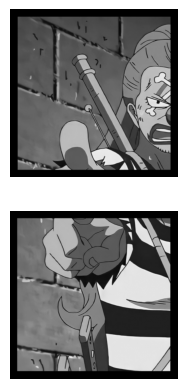

In [94]:
def rotate(img,angle):
    h, w = img.shape
    angle = int(angle) % 360
    if angle == 0: return img
    elif angle == 90:
        rot = np.zeros((w, h), dtype=img.dtype)
        for i in range(h):
            for j in range(w): rot[j, h - 1 - i] = img[i, j]
        return rot
    elif angle == 180:
        rot = np.zeros_like(img, dtype=img.dtype)
        for i in range(h):
            for j in range(w): rot[h - 1 - i, w - 1 - j] = img[i, j]
        return rot
    elif angle == 270:
        rot = np.zeros((w, h), dtype=img.dtype)
        for i in range(h):
            for j in range(w): rot[w - 1 - j, i] = img[i, j]
        return rot
    return img

img1_gray = rotate(img1_gray,90)
plt.subplot(2,1,1)
plt.imshow(img1_gray,cmap="gray")
plt.axis('off')

img2_gray = rotate(img2_gray,270)
plt.subplot(2,1,2)
plt.imshow(img2_gray,cmap="gray")
plt.axis('off')

Seperti analisis sebelumnya, beberapa citra perlu diputar untuk menyerupai betuk aslinya. Contohnya seperti citra1 dan citra 2. Citra 1 diputar sejauh 90 derajat searah jarum jam. Sedangkan citra 2, diputar sejauh 270 derajat searah jarum jam.

(np.float64(-0.5), np.float64(368.5), np.float64(368.5), np.float64(-0.5))

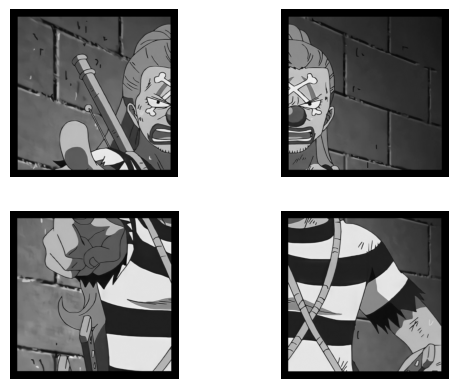

In [95]:
def flip(img,mode='X'):
    h, w = img.shape
    hasil = np.zeros((h, w), dtype=img.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = img[i, w - 1 - j]
            elif mode == 'Y':
                hasil[i, j] = img[h - 1 - i, j]
    return hasil

img3_gray = rotate(img3_gray,180)
img3_gray = flip(img3_gray,'X')

img4_gray = flip(img4_gray,'X')

plt.subplot(2,2,1)
plt.imshow(img1_gray,cmap="gray")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img3_gray,cmap="gray")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img2_gray,cmap="gray")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img4_gray,cmap="gray")
plt.axis('off')

Dapat dilihat pada citra-citra di atas, ada beberapa citra yang perlu dilakukan operasi posisi selain rotasi. Setelah dilaukan rotasi, citra-citra tersebut masih belum sesuai dengan bentuk aslinya sehingga perlu dilakukan operasi flip atau membalik citra seperti terkena cermin.

In [96]:
print(img1_gray.shape)
print(img2_gray.shape)
print(img3_gray.shape)
print(img4_gray.shape)

(369, 369)
(369, 369)
(369, 369)
(369, 369)


(336, 336)
(336, 336)
(336, 336)
(336, 336)


(np.float64(-0.5), np.float64(335.5), np.float64(335.5), np.float64(-0.5))

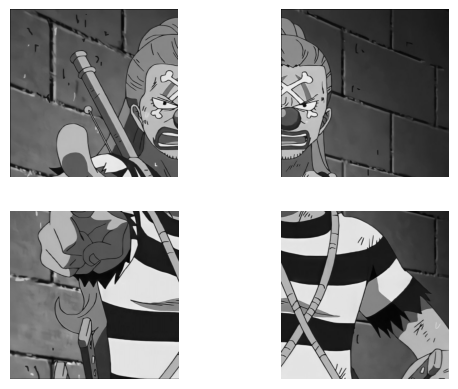

In [97]:
img1_gray = img1_gray[16:352,16:352]
print(img1_gray.shape)

img2_gray = img2_gray[16:352,16:352]
print(img1_gray.shape)

img3_gray = img3_gray[16:352,16:352]
print(img1_gray.shape)

img4_gray = img4_gray[16:352,16:352]
print(img1_gray.shape)

plt.subplot(2,2,1)
plt.imshow(img1_gray,cmap="gray")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img3_gray,cmap="gray")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img2_gray,cmap="gray")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img4_gray,cmap="gray")
plt.axis('off')

Setelah mengubah posisi citra, masih terdapat border-border hitam yang dapat mengganggu penggabungan citra. Sehingga diperlukan pemotongan terhadap border-border tersebut.

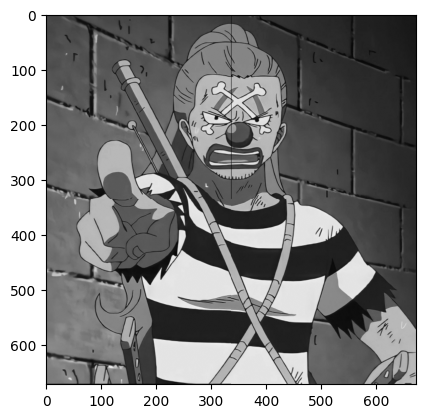

In [98]:
h,w = img1_gray.shape
canvas = np.zeros((h*2,w*2),dtype=img1_gray.dtype)
canvas[0:h,0:w] = img1_gray
canvas[h:h*2,0:w] = img2_gray
canvas[0:h,w:w*2] = img3_gray
canvas[h:h*2,w:w*2] = img4_gray
canvas = canvas//2
plt.imshow(canvas,cmap='gray')

Pemotongan border-border hitam sebelumnya memudahkan citra untuk disatukan menjadi satu citra utuh. Walapun terdapat garis vertikal hitam pada citra, citra berhasil disatukan. Garis hitam vertikal tersebut kemungkinan karena efek rotasi atau skala untuk memotong border hitam sebelumnya kurang presisi.

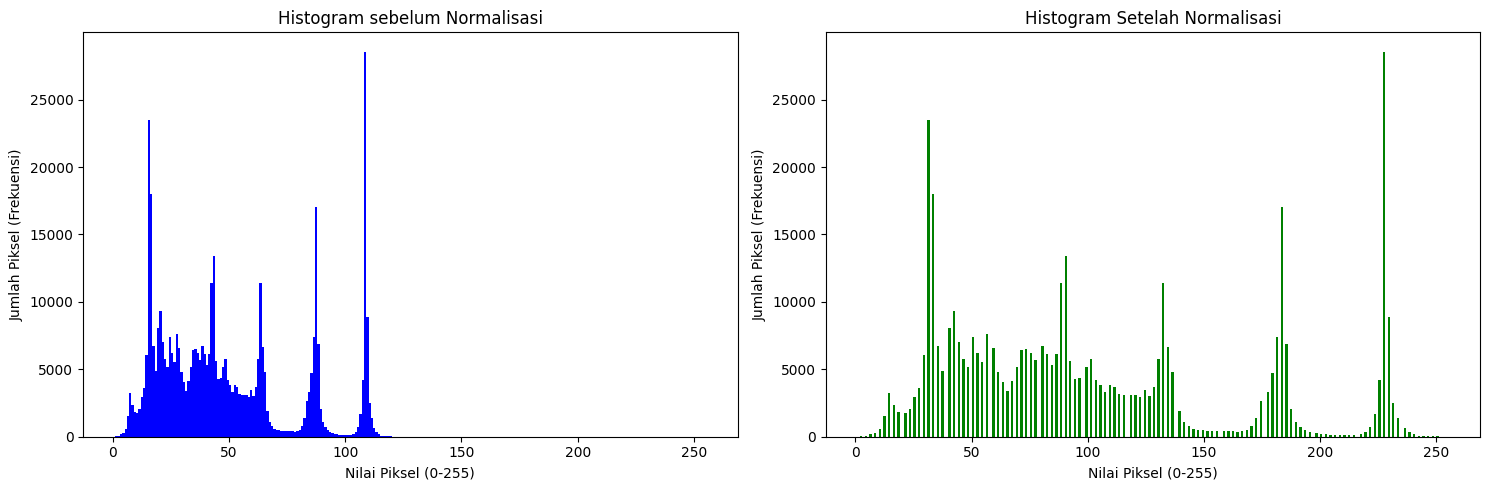

In [99]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.hist(canvas.ravel(),bins=256 ,range=[0,256],color='blue')
plt.title('Histogram sebelum Normalisasi')
plt.xlabel('Nilai Piksel (0-255)')
plt.ylabel('Jumlah Piksel (Frekuensi)')

canvas_float = canvas.astype(np.float32)
nilai_min = canvas_float.min()
nilai_max = canvas_float.max()

# Menerapkan rumus Min-Max
canvas_normalized = 255.0 * ((canvas_float - nilai_min) / (nilai_max - nilai_min))
plt.subplot(1,2,2)
plt.hist(canvas_normalized.ravel(),bins=256 ,range=[0,256],color='green')
plt.title('Histogram Setelah Normalisasi')
plt.xlabel('Nilai Piksel (0-255)')
plt.ylabel('Jumlah Piksel (Frekuensi)')

plt.tight_layout()

Berikut perbedaan histogram pada citra sebelum dan sesudah normalisasi. Sebelum dinormalisasi, intesistas piksel citra menumpuk pada bagian gelap. Sedangkan setelah dinormalisasi, intensistas citra menjadi lebih terdistribusi.

(np.float64(-0.5), np.float64(671.5), np.float64(671.5), np.float64(-0.5))

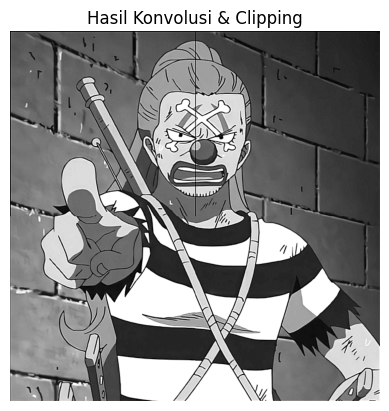

In [100]:
img_float = canvas_normalized.astype(np.float32)

tinggi_img, lebar_img = img_float.shape

kernel = np.array([
    [-0.1, -0.1, -0.1, -0.1], 
    [-0.1,  0.6,  0.6, -0.1], 
    [-0.1,  0.6,  0.6, -0.1], 
    [-0.1, -0.1, -0.1, -0.1]
], dtype=np.float32)

tinggi_kernel, lebar_kernel = kernel.shape

pad_t = tinggi_kernel // 2
pad_l = lebar_kernel // 2

img_padded = np.zeros((tinggi_img + 2 * pad_t, lebar_img + 2 * pad_l), dtype=np.float32)

img_padded[pad_t : pad_t + tinggi_img, pad_l : pad_l + lebar_img] = img_float


img_conv = np.zeros_like(img_float)

for i in range(tinggi_img):
    for j in range(lebar_img):
        potongan_gambar = img_padded[i : i + tinggi_kernel, j : j + lebar_kernel]
        
        hasil_perhitungan = np.sum(potongan_gambar * kernel)
        
        img_conv[i, j] = hasil_perhitungan


img_conv[img_conv < 0] = 0

img_conv[img_conv > 255] = 255


img_final = img_conv.astype(np.uint8)

plt.imshow(img_final, cmap='gray')
plt.title('Hasil Konvolusi & Clipping')
plt.axis('off')

Dapat dilihat pada citra di atas, tak ada perubahan yang signifikan yang dapat dilihat oleh mata. Namun, tentunya komputer dapat melihat perbedaan pada citra karena komputer melihat jumlah piksel dan intensitasnya yang tak dapat dilihat oleh kita. Perubahan nilai piksel tentunya bisa disebabkn oleh operasi sseperti konvolusi.